#### What is the **most optimal skill** to learn for ***Data Analysts***?

In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Accessing raw data from data access function
from data_jobs.data_access import load_data

# Cleaning the data with cleaning function/s
from data_jobs.data_process import clean_date, clean_skills


df = load_data()
df = clean_date(df)
df = clean_skills(df)

print("Lib/s loaded and data ready")

c:\Users\hersh\anaconda3\envs\data_jobs_env\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Lib/s loaded and data ready


In [3]:
'''
sorting df by job role and country of interest.
dropping na values in salary column.
'''
df_DA_IN = df.query('job_title_short == "Data Analyst" and job_country == "India"').copy()

df_DA_IN.dropna(subset=['salary_year_avg'], inplace=True)

df_DA_IN = df_DA_IN.explode('job_skills')


In [4]:
# grouping top 10 most popular skills, sorting them by salary high to low.
df_DA_skills = (df_DA_IN.groupby('job_skills')['salary_year_avg']
                 .agg(['count','median'])
                 .sort_values(by='count', ascending=False)
                 
                 
)
df_DA_skills = df_DA_skills.rename(columns={'count': 'skill_count', 
                                            'median': 'median_salary'})
DA_IN_job_count = len(df_DA_IN)

df_DA_skills['skill_percent'] = round(
    df_DA_skills['skill_count'] / DA_IN_job_count * 100,
    2
    )

df_DA_skills_high_demand = df_DA_skills[df_DA_skills['skill_percent'] >= 2]

df_DA_skills_high_demand

,skill_count,median_salary,skill_percent
job_skills,,,
sql,46,96050.00,11.25
excel,39,98500.00,9.54
python,36,96050.00,8.80
tableau,20,108087.50,4.89
r,18,79200.00,4.40
power bi,17,111175.00,4.16
azure,15,93600.00,3.67
aws,12,79200.00,2.93
oracle,11,79200.00,2.69


In [5]:
plt.rcParams.update({ 'font.weight': 'bold',
                     'font.size': 10,
    'axes.titleweight': 'bold',
    'axes.labelweight': 'bold',
    'axes.labelcolor': "#2A2B2E",
    'text.color': '#2A2B2E',
    'axes.titlecolor': '#2A2B2E',
    'xtick.color': "#2A2B2E",
    'ytick.color': '#2A2B2E',
    'axes.titlesize':16,
    'axes.labelsize':12
    })

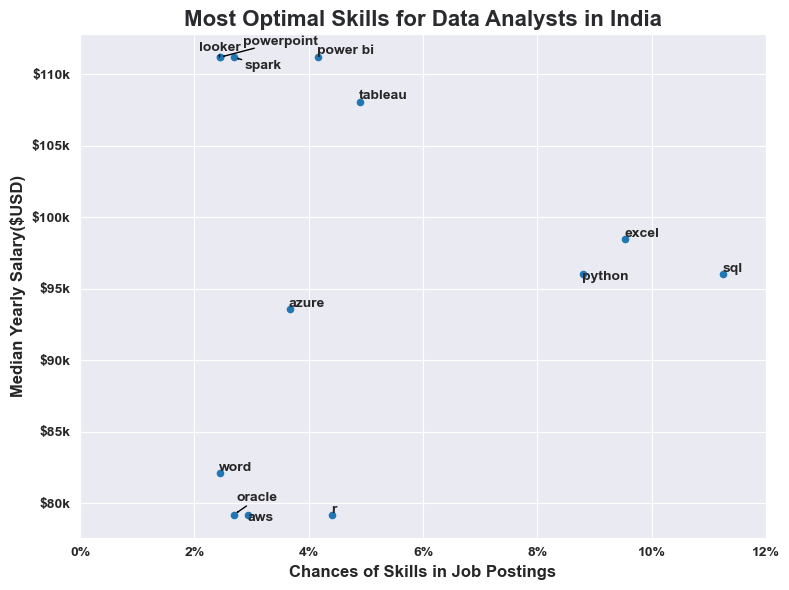

In [6]:
from adjustText import adjust_text

sns.set_style('darkgrid')
df_DA_skills_high_demand.plot(kind='scatter',
                 x='skill_percent',
                 y='median_salary',
                 figsize=(8, 6)
                 )

texts = []
for i, txt in enumerate(df_DA_skills_high_demand.index):
    texts.append(plt.text(
        df_DA_skills_high_demand['skill_percent'].iloc[i], 
        df_DA_skills_high_demand['median_salary'].iloc[i], 
        txt
        ))
# adjusting txt at scatter points  
adjust_text(texts, arrowprops=dict(arrowstyle='->', color='black'))

plt.xlim(0, 12)
# formatting y-axis values 
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(
    lambda y, pos: f'${int(y/1000)}k' ))

plt.gca().xaxis.set_major_formatter(plt.FuncFormatter(
    lambda x, pos: f'{int(x)}%' ))

plt.title('Most Optimal Skills for Data Analysts in India')

plt.ylabel('Median Yearly Salary($USD)')
plt.xlabel('Chances of Skills in Job Postings')

plt.tight_layout()
plt.show()

#### Plotting the same ***scatterplot*** with ***core technologies*** of these ***skills***

In [7]:
df['job_type_skills'].head()

0                                                  NaN
1    {'analyst_tools': ['power bi', 'tableau'], 'pr...
2    {'analyst_tools': ['dax'], 'cloud': ['azure'],...
3    {'cloud': ['aws'], 'libraries': ['tensorflow',...
4    {'cloud': ['oracle', 'aws'], 'other': ['ansibl...
Name: job_type_skills, dtype: str

In [8]:
import ast
# Drop NaN
df_clean = df.dropna(subset=['job_type_skills'])

# Remove duplicates
df_clean = df_clean.drop_duplicates(subset=['job_type_skills'])

# Convert string → dictionary
df_clean['job_type_skills'] = df_clean['job_type_skills'].apply(ast.literal_eval)

# combine dictionaries
technology_dict = {}

for d in df_clean['job_type_skills']:
    for key, value in d.items():
        if key not in technology_dict:
            technology_dict[key] = []
        technology_dict[key].extend(value)

# remove duplicates (convert to set then back to list)
for key in technology_dict:
    technology_dict[key] = list(set(technology_dict[key]))

'''
gives a single dictionary with core technologies as keys
and their related unique skills list as values.
'''
technology_dict

{'analyst_tools': ['splunk',
  'sas',
  'datarobot',
  'microstrategy',
  'excel',
  'ssrs',
  'ms access',
  'alteryx',
  'sap',
  'powerbi',
  'nuix',
  'outlook',
  'esquisse',
  'looker',
  'dax',
  'msaccess',
  'cognos',
  'spreadsheet',
  'spss',
  'tableau',
  'visio',
  'ssis',
  'sharepoint',
  'power bi',
  'word',
  'sheets',
  'qlik',
  'powerpoint'],
 'programming': ['f#',
  'elixir',
  'mongodb',
  'javascript',
  'css',
  'crystal',
  'sas',
  'objective-c',
  'delphi',
  'julia',
  'ocaml',
  'dart',
  'assembly',
  't-sql',
  'golang',
  'sql',
  'c++',
  'solidity',
  'lisp',
  'shell',
  'clojure',
  'rust',
  'vba',
  'html',
  'erlang',
  'no-sql',
  'php',
  'apl',
  'nosql',
  'c#',
  'bash',
  'groovy',
  'mongo',
  'r',
  'ruby',
  'typescript',
  'go',
  'powershell',
  'lua',
  'fortran',
  'sass',
  'cobol',
  'swift',
  'visual basic',
  'python',
  'matlab',
  'scala',
  'c',
  'pascal',
  'haskell',
  'visualbasic',
  'kotlin',
  'vb.net',
  'java',
  'p

In [ ]:
# converting dictionary into df, exploding skills column.
df_technology = pd.DataFrame(list(technology_dict.items()), columns=['technology', 'skills'])

df_technology = df_technology.explode('skills')

df_technology


,technology,skills
0,analyst_tools,splunk
0,analyst_tools,sas
0,analyst_tools,datarobot
0,analyst_tools,microstrategy
0,analyst_tools,excel
...,...,...
9,sync,zoom
9,sync,unify
9,sync,mattermost
9,sync,twilio


In [ ]:
#  merging two dfs on skills columns in each.
df_plot = df_DA_skills_high_demand.merge(df_technology, left_on='job_skills', right_on='skills')
df_plot

,skill_count,median_salary,skill_percent,technology,skills
0,46,96050.00,11.25,programming,sql
1,39,98500.00,9.54,analyst_tools,excel
2,36,96050.00,8.80,programming,python
3,20,108087.50,4.89,analyst_tools,tableau
4,18,79200.00,4.40,programming,r
5,17,111175.00,4.16,analyst_tools,power bi
6,15,93600.00,3.67,cloud,azure
7,12,79200.00,2.93,cloud,aws
8,11,79200.00,2.69,cloud,oracle
9,11,111175.00,2.69,libraries,spark


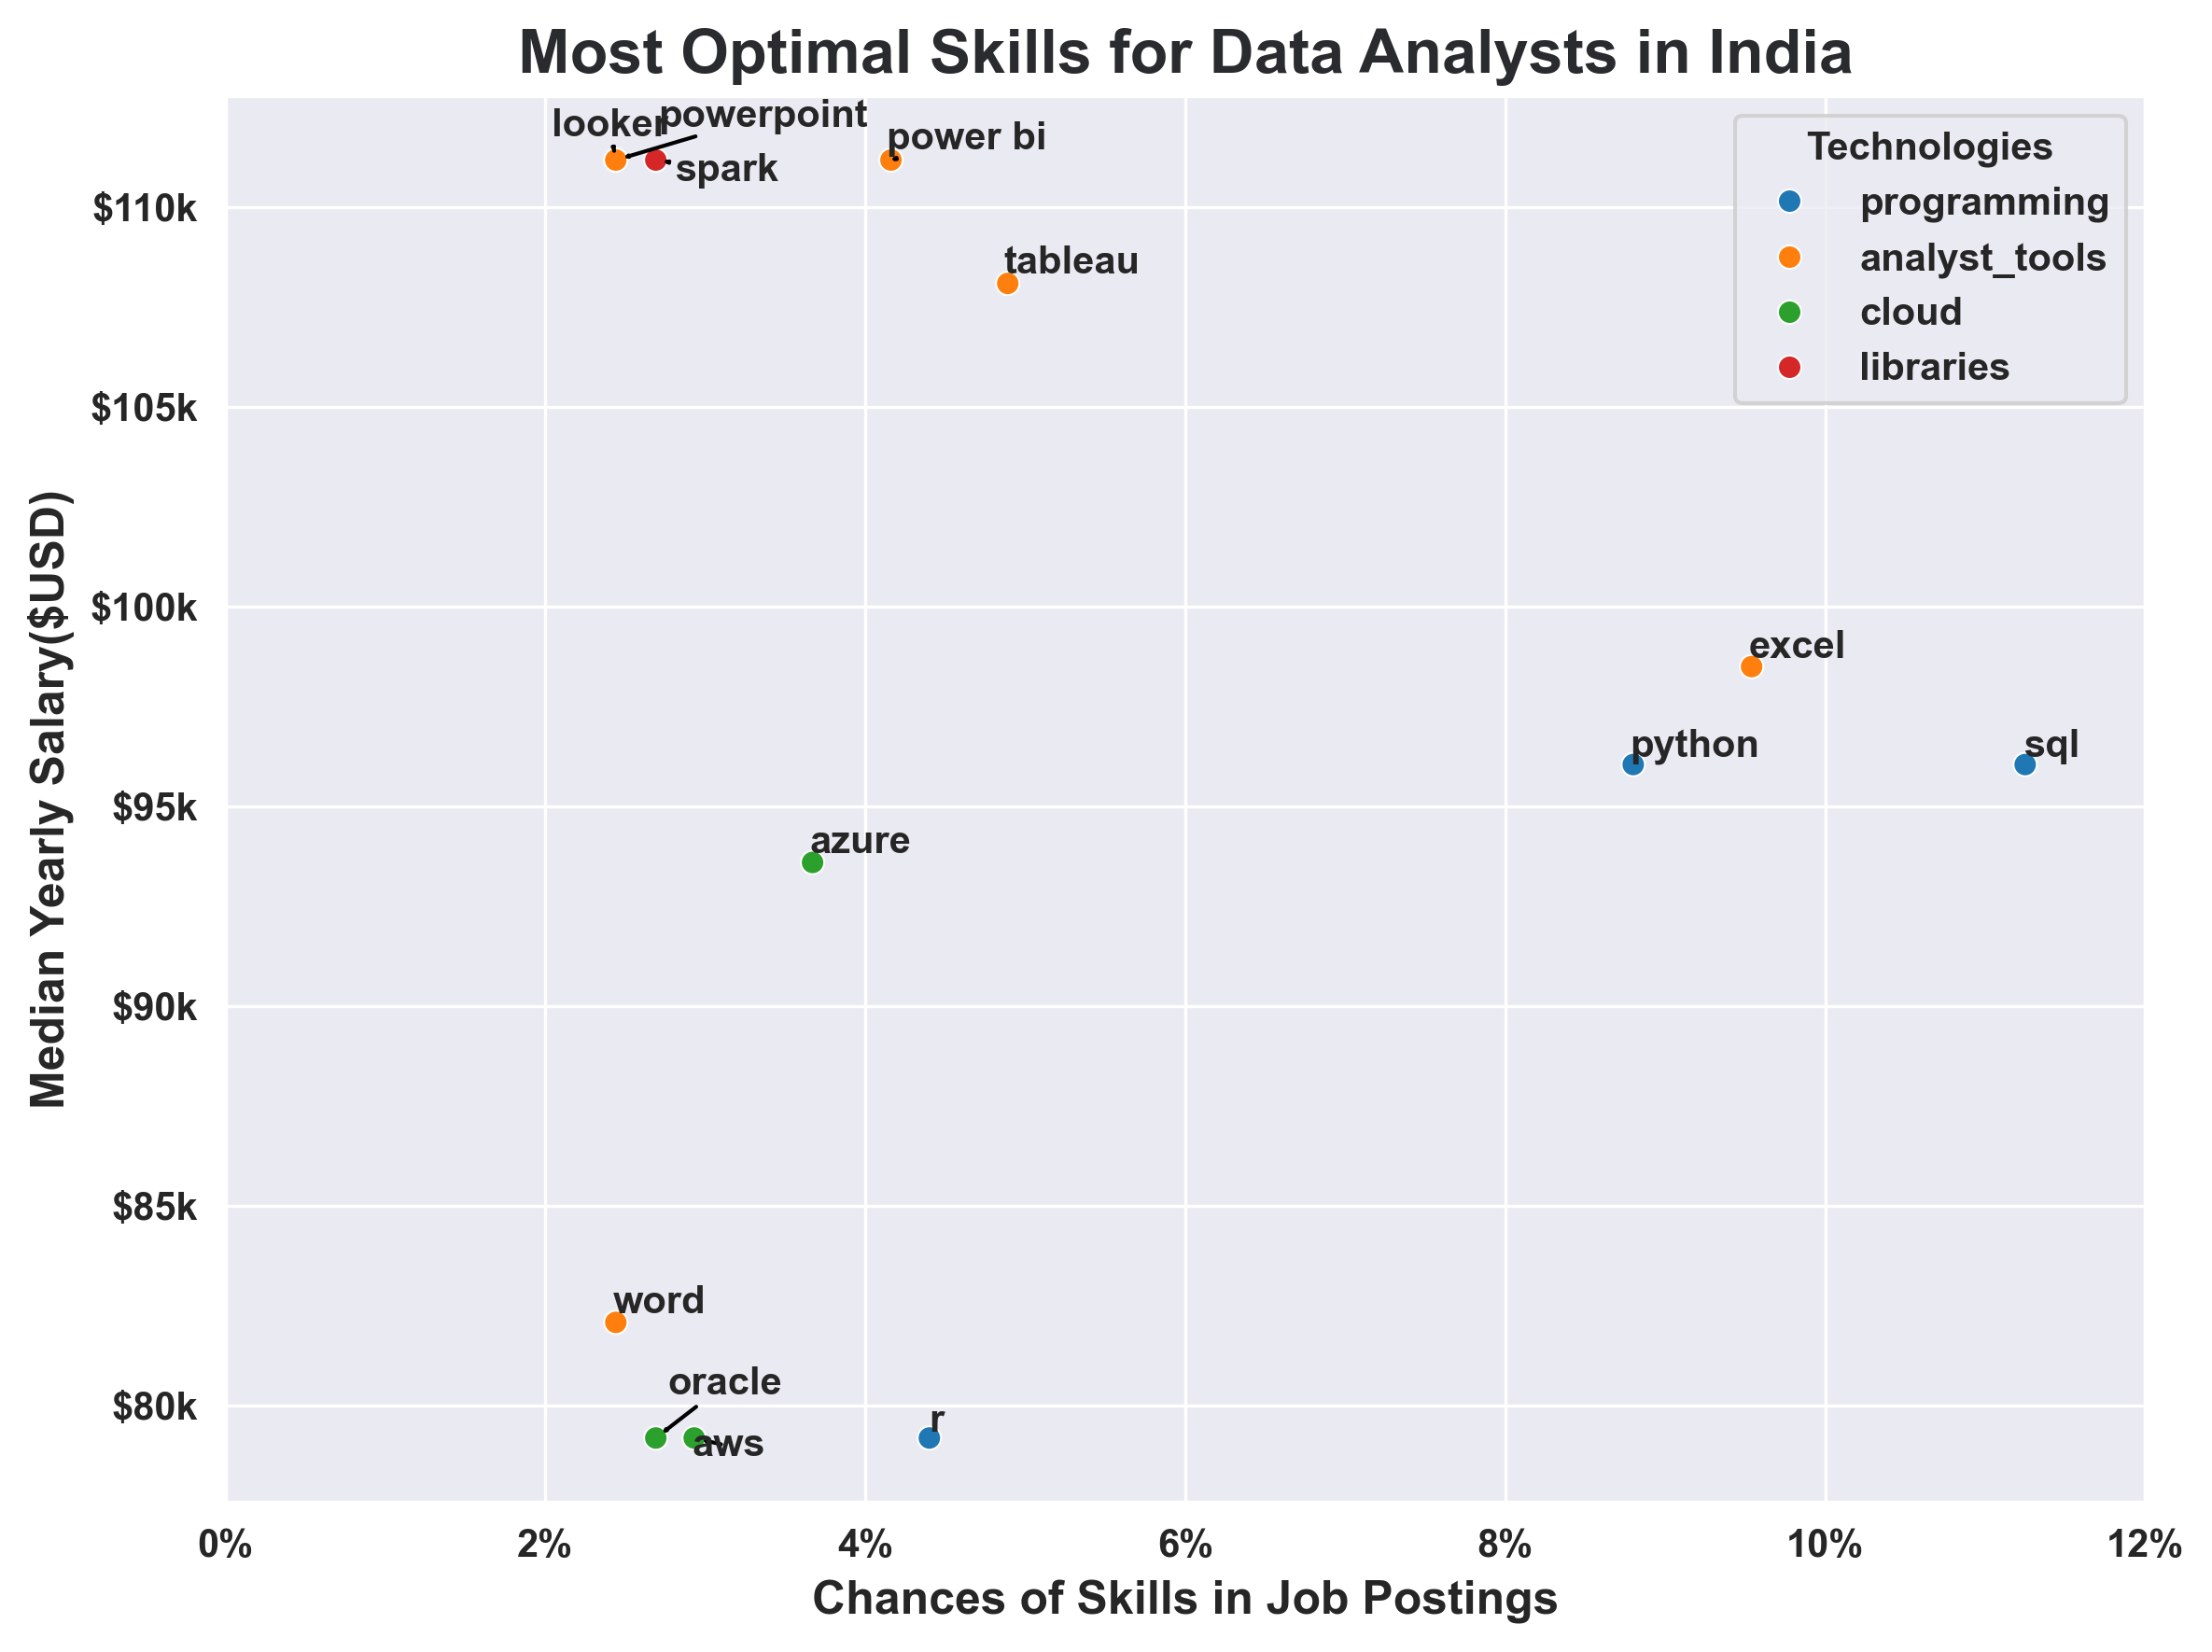

In [18]:
from adjustText import adjust_text

plt.figure(figsize=(8, 6), dpi=300)
sns.set_style('darkgrid')

sns.scatterplot(data= df_plot, x='skill_percent', y='median_salary',
                hue='technology')

texts = []
for i, txt in enumerate(df_plot.skills):
    texts.append(plt.text(
        df_plot['skill_percent'].iloc[i], 
        df_plot['median_salary'].iloc[i], 
        txt
        ))
# adjusting txt at scatter points  
adjust_text(texts, arrowprops=dict(arrowstyle='->', color='black'))

plt.xlim(0, 12)

# formatting y-axis values 
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(
    lambda y, pos: f'${int(y/1000)}k' ))

# formatting x-axis values 
plt.gca().xaxis.set_major_formatter(plt.FuncFormatter(
    lambda x, pos: f'{int(x)}%' ))

plt.title('Most Optimal Skills for Data Analysts in India')
plt.legend(title='Technologies')

plt.ylabel('Median Yearly Salary($USD)')
plt.xlabel('Chances of Skills in Job Postings')

plt.tight_layout()
plt.show()